# MLP 

Implementation of a Multi-Layer Perceptron for image classification on CIFAR-10.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math
import os

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "DATA"))
CKPT_DIR = './checkpoints/1_MLP'
os.makedirs(CKPT_DIR, exist_ok=True)

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device = {device}")

device = cuda


---
# 0. Dataset

CIFAR-10 : 60k color images of size 32×32 split into 50k training samples and 10k test samples, distributed across 10 classes : airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

In [2]:
BATCH_SIZE = 128
IMG_SIZE   = 32
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),  #Flips the image horizontally (left ↔ right) with probability 0.5
    transforms.RandomCrop(32, padding=4), #Pad the 32×32 image with 4 black pixels on each side → 40×40 and Randomly crop a 32×32 region from this 40×40 image
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_set = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True,  download=True, transform=train_tf)
test_set  = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=test_tf)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

sample_img, _ = train_set[0]
CHANNELS, H, W = sample_img.shape
NUM_CLASSES    = len(train_set.classes)
print(f"train {len(train_set)} | test {len(test_set)}")
print(f"Num classes : {NUM_CLASSES}  {train_set.classes}")

train 50000 | test 10000
Num classes : 10  ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Data augmentation

To prevent overfitting on the 50k training images, we apply two stochastic transforms to each training sample :

`RandomHorizontalFlip()` : flips the image horizontally with probability 0.5. Forces invariance to left/right orientation.

`RandomCrop(32, padding=4)` : pads the image with 4 zero pixels on each side, then randomly crops back a 32×32 region. Simulates small spatial translations.


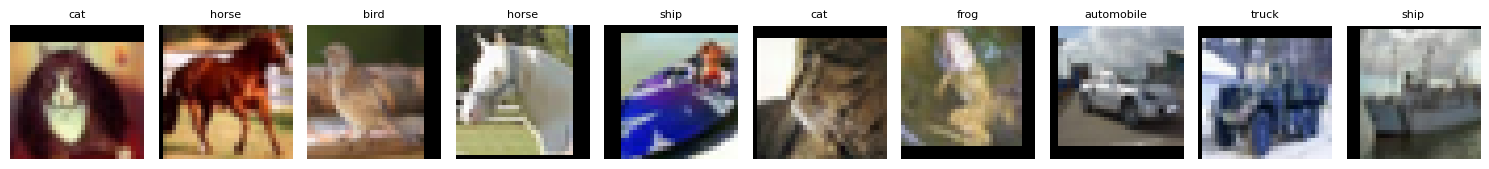

In [3]:
def unnorm(img):
    m = torch.tensor(MEAN).view(3, 1, 1)
    s = torch.tensor(STD).view(3, 1, 1)
    return (img * s + m).clamp(0, 1)

indices = torch.randint(0, len(train_set), (10,))
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, idx in enumerate(indices):
    img, label = train_set[idx]
    axes[i].imshow(unnorm(img).permute(1, 2, 0).numpy())
    axes[i].set_title(train_set.classes[label], fontsize=8)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

---
# 1. MLP architecture

**Input :** $x \in \mathbb{R}^{B \times C \times H \times W}$

$$x_{\text{flat}} = \text{Flatten}(x) \in \mathbb{R}^{B \times \text{in\_dim}}$$

$$h_1 = \text{ReLU}(x_{\text{flat}}\, W_1^T + b_1) \in \mathbb{R}^{B \times \text{hidden}}, \quad W_1 \in \mathbb{R}^{\text{hidden} \times \text{in\_dim}},\ b_1 \in \mathbb{R}^{\text{hidden}},\ h_1 \in \mathbb{R}^{B \times \text{hidden}}$$

$$h_2 = \text{ReLU}(h_1\, W_2^T + b_2) \in \mathbb{R}^{B \times \text{hidden}}, \quad W_2 \in \mathbb{R}^{\text{hidden} \times \text{hidden}},\ b_2 \in \mathbb{R}^{\text{hidden}},\ h_2 \in \mathbb{R}^{B \times \text{hidden}}$$

$$\text{logits} = h_2\, W_3^T + b_3 \in \mathbb{R}^{B \times \text{num\_classes}}, \quad W_3 \in \mathbb{R}^{\text{num\_classes} \times \text{hidden}},\ b_3 \in \mathbb{R}^{\text{num\_classes}},\ \text{logits} \in \mathbb{R}^{B \times \text{num\_classes}}$$

In [4]:
#Hyperparameters
in_dim = CHANNELS * H * W
hidden = 512 
NUM_EPOCHS = 60 

In [5]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, num_classes),
        )
    def forward(self, x): return self.net(x)


model = MLP(in_dim,hidden,NUM_CLASSES).to(device)

params    = sum(p.numel() for p in model.parameters())
params_th = in_dim * hidden + hidden + hidden**2 + hidden + hidden * NUM_CLASSES + NUM_CLASSES

print(f"empirical : {params:,}")
print(f"theory    : {params_th:,}")
print(f"match     : {params == params_th}")

empirical : 1,841,162
theory    : 1,841,162
match     : True


---
# 2. Training

Training over 30 epochs with **cross-entropy** as criterion and **Stochastic Gradient Descent** as optimizer.


### Criterion : Cross-entropy

The network outputs $\text{logits} \in \mathbb{R}^{B \times \text{num\_classes}}$. We process **one row at a time** : $z \in \mathbb{R}^{\text{num\_classes}}$ is one row of $\text{logits}$, and we average the per-row loss over the batch at the end.

For $i \in \{0, \dots, \text{num\_classes} - 1\}$, softmax turns $z$ into a probability distribution :

$$p_i = \text{softmax}(z_i) = \frac{e^{z_i}}{\displaystyle\sum_{j=0}^{\text{num\_classes}-1} e^{z_j}}$$

Given the true class $y \in \{0, \dots, \text{num\_classes}-1\}$, the loss is :

$$\mathcal{L}_{\text{row}} = -\log p_y$$

Computing softmax then taking the log is numerically unstable (the exponentials can overflow). Instead we use the **log-softmax trick** :

$$\log p_i = z_i - \log \sum_{j=0}^{\text{num\_classes}-1} e^{z_j}$$

The second term is computed with the **logsumexp trick**. Let $m = \displaystyle\max_{j \in \{0, \dots, \text{num\_classes}-1\}} z_j$ :

$$\sum_{j=0}^{\text{num\_classes}-1} e^{z_j} = \sum_{j=0}^{\text{num\_classes}-1} e^{z_j - m + m} = e^m \sum_{j=0}^{\text{num\_classes}-1} e^{z_j - m}$$

Taking the log :

$$\log \sum_{j=0}^{\text{num\_classes}-1} e^{z_j} = m + \log \sum_{j=0}^{\text{num\_classes}-1} e^{z_j - m}$$

Since $z_j - m \leq 0$ for all $j$, every term $e^{z_j - m} \in\ ]0, 1]$ — no overflow possible.

So we have :

$$\mathcal{L}_{\text{row}} = -z_y + m + \log \sum_{j=0}^{\text{num\_classes}-1} e^{z_j - m}$$

We repeat this computation for the $B$ rows of $\text{logits}$ and average :

$$\mathcal{L} = \frac{1}{B} \sum_{\text{row} \in \text{logits}} \mathcal{L}_{\text{row}}$$

### Optimizer : Stochastic Gradient Descent (SGD)

The gradient $\nabla_\theta \mathcal{L}$ tells us the direction in which the loss increases the most. To **minimize** the loss, we go in the opposite direction:

$$\theta_{t+1} = \theta_t - \eta \cdot \nabla_\theta \mathcal{L}(\theta_t)$$

where $\eta$ is the **learning rate** 



In [6]:
def slope_per_epoch(values, window=5):
    if len(values) < 2:
        return float('inf')
    w = min(window, len(values))
    y = np.array(values[-w:]); x = np.arange(w)
    return float(np.polyfit(x, y, 1)[0])


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

In [7]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

PATIENCE = 8
train_losses, test_losses = [], []
train_accs,   test_accs   = [], []
best_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    train_losses.append(tr_loss); test_losses.append(te_loss)
    train_accs.append(tr_acc);   test_accs.append(te_acc)
    print(f"epoch {epoch:2d}/{NUM_EPOCHS} | train {tr_loss:.4f} {tr_acc*100:.1f}% | test {te_loss:.4f} {te_acc*100:.1f}%")

    if te_acc > best_acc:
        best_acc = te_acc
        torch.save({'epoch': epoch, 'model': model.state_dict(),
                    'train_losses': train_losses, 'test_losses': test_losses,
                    'train_accs':   train_accs,   'test_accs':   test_accs},
                   os.path.join(CKPT_DIR, 'mlp_best.pt'))

    best_epoch = test_accs.index(max(test_accs))
    if (len(test_accs) - 1 - best_epoch) >= PATIENCE:
        print(f"  early stop : converged (no improvement for {PATIENCE} epochs)")
        break

print(f"\nbest test acc : {max(test_accs)*100:.2f}%")
print(f"converged at  : epoch {test_accs.index(max(test_accs))+1}")
print(f"final slope   : {slope_per_epoch([a*100 for a in test_accs]):.3f} %/epoch")

epoch  1/60 | train 2.0606 25.9% | test 1.9442 32.7%
epoch  2/60 | train 1.8823 32.7% | test 1.8273 36.2%
epoch  3/60 | train 1.7928 36.0% | test 1.7558 38.5%
epoch  4/60 | train 1.7300 38.4% | test 1.7090 39.4%
epoch  5/60 | train 1.6864 39.8% | test 1.6687 40.9%
epoch  6/60 | train 1.6466 41.5% | test 1.6284 42.4%
epoch  7/60 | train 1.6167 42.2% | test 1.6202 42.4%
epoch  8/60 | train 1.5897 43.5% | test 1.5991 43.3%
epoch  9/60 | train 1.5663 44.3% | test 1.5614 44.5%
epoch 10/60 | train 1.5442 45.1% | test 1.5708 43.9%
epoch 11/60 | train 1.5264 45.8% | test 1.5475 45.1%
epoch 12/60 | train 1.5105 46.0% | test 1.5412 45.3%
epoch 13/60 | train 1.4976 46.4% | test 1.5230 45.6%
epoch 14/60 | train 1.4855 46.9% | test 1.5172 46.0%
epoch 15/60 | train 1.4716 47.6% | test 1.4890 46.9%
epoch 16/60 | train 1.4591 48.0% | test 1.4912 47.5%
epoch 17/60 | train 1.4511 48.1% | test 1.4765 47.3%
epoch 18/60 | train 1.4394 48.7% | test 1.4718 47.8%
epoch 19/60 | train 1.4305 49.1% | test 1.4797

## Curves

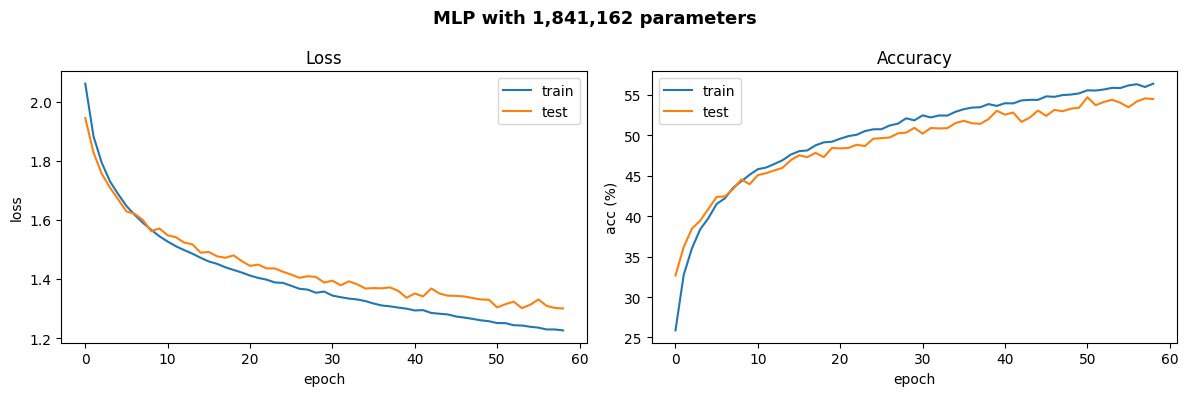

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='train'); ax1.plot(test_losses, label='test')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.legend(); ax1.set_title('Loss')
ax2.plot([a*100 for a in train_accs], label='train'); ax2.plot([a*100 for a in test_accs], label='test')
ax2.set_xlabel('epoch'); ax2.set_ylabel('acc (%)'); ax2.legend(); ax2.set_title('Accuracy')
plt.suptitle(f'MLP with {params:,} parameters', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
# 3. Results

Plot 10 random predictions from the test set 

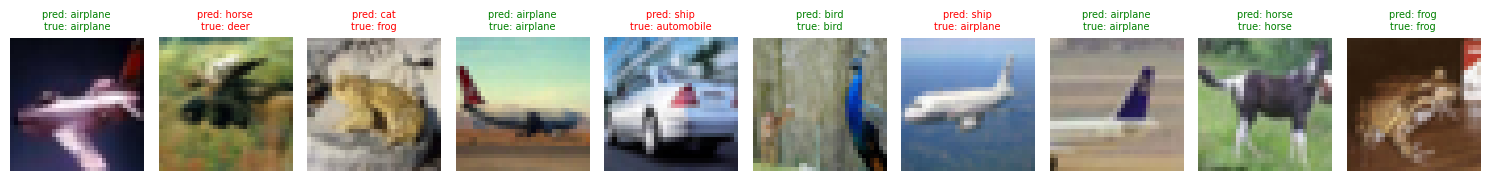

In [9]:
model.eval()
indices = torch.randint(0, len(test_set), (10,))

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, idx in enumerate(indices):
    img, true_label = test_set[idx]
    with torch.no_grad():
        logits = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(dim=1).item()
    axes[i].imshow(unnorm(img).permute(1, 2, 0).numpy())
    color = 'green' if pred == true_label else 'red'
    axes[i].set_title(f"pred: {test_set.classes[pred]}\ntrue: {test_set.classes[true_label]}",
                       fontsize=7, color=color)
    axes[i].axis('off')
plt.tight_layout()
plt.show()